In [1]:
import pandas as pd
import zipfile
from datetime import timedelta

# --------------------------------------------------
# Configuration (paths, chunk sizes, etc.)(This part tells the program where the MIMIC data is stored and how much data to read at a time.)
# --------------------------------------------------
zip_path = r"E:\Universität\Winter semester 25\Data science\mimic documentation\mimic-iii-clinical-database-1.4.zip"
# small tables can be loaded at once; large ones must be streamed

MAX_ROWS_SMALL = None          # all rows for small tables
CHUNK_SIZE = 500_000           # rows per chunk when streaming events
print("this section was scuccessfully executed")

this section was scuccessfully executed


In [2]:
# --------------------------------------------------
#  Define which ITEMIDs correspond to the vitals/labs we need(Lists all the ICU vital signs and lab test codes we want to extract from CHARTEVENTS and LABEVENTS)
# --------------------------------------------------

# VITALS (from CHARTEVENTS)
vital_itemids = {
    "HR":          [211, 220045],                               # Heart rate
    "SBP":         [51, 442, 455, 6701, 220179, 220050],        # Systolic blood pressure (multiple variants)
    "RR":          [618, 220210],                               # Respiratory rate
    "Temp":        [676, 223761],                               # Body temperature
    "SpO2":        [646, 220277],                               # Oxygen saturation
    "GCS":         [454, 223900],                               # Glasgow Coma Scale components
    "DBP":         [8368, 8441, 8555, 220051],                  # Diastolic blood pressure
    "MAP":         [456, 52, 6702, 220052],                     # Mean arterial pressure
    "FiO2":        [190, 3420, 223835],                         # Fraction of inspired oxygen
    "O2Flow":      [470, 471, 223834],                          # Oxygen flow rate (L/min)
    "UrineOut":    [40055, 43175, 40069, 226559],               # Urine output (various sources)
    "Weight":      [763, 224639],                               # Admission / daily weight

}
# LABS (from LABEVENTS)
lab_itemids = {
    "Lactate":     [50813],   # blood lactate level
    "Creatinine":  [50912],   # kidney function marker
    "BUN":         [51006],   # blood urea nitrogen
    "WBC":         [51300],   # white blood cell count
    "HGB":         [50811],   # hemoglobin
    "Platelets":   [51265],   # platelet count
    "Sodium":      [50983],   # serum sodium
    "Potassium":   [50971],   # serum potassium
    "Bicarbonate": [50882],   # serum bicarbonate (CO₂)
    "AG":          [50868],   # anion gap 
    "Bilirubin":   [50885],   # total bilirubin (liver function, very predictive)
    "pH":          [50820],   # Arterial pH
    "PaO2":        [50821],   # Arterial oxygen pressure
    "PaCO2":       [50818],   # Arterial CO2 pressure
    "BaseExcess":  [50802],   # Base excess

    # Renal / metabolic / electrolytes
    "Chloride":     [50902],   # Chloride
    "Glucose":      [50931],   # Glucose
    "Calcium":      [50893],   # Calcium (total)
    "IonCalcium":   [50808],   # Ionized calcium
    "Magnesium":    [50960],   # Magnesium
    "Phosphate":    [50970],   # Phosphate

    # Coagulation
    "INR":          [51237],   # INR
    "PT":           [51274],   # Prothrombin time
    "aPTT":         [51275],   # Activated PTT

    # Liver / nutrition / reserve
    "Albumin":      [50862],   # Albumin (very predictive for long-term mortality)
    "AST":          [50878],   # AST(Elevation reflects hepatocellular damage)
    "ALT":          [50861],   # ALT(Indicates hepatocyte injury)
    "AlkPhos":      [50863],   # Alkaline phosphatase

    # Hematology extras
    "HCT":          [51221],   # Hematocrit
    "RDW":          [51277],   # Red cell distribution width
    "Neutrophils":  [51256],   # Neutrophils %
    "Lymphocytes":  [51244],   # Lymphocytes %
}

# flatten ITEMID lists for filtering
vital_itemids_all = [x for ids in vital_itemids.values() for x in ids]
lab_itemids_all   = [x for ids in lab_itemids.values()   for x in ids]
print("this section was scuccessfully executed")


this section was scuccessfully executed


In [3]:
# --------------------------------------------------
# Helper function for small tables (loads from ZIP) (This part loads the smaller MIMIC tables directly from the ZIP file because they are easy to load)
# --------------------------------------------------
def load_from_zip(zip_path, pattern, usecols, nrows=None):
    """Load a single .csv.gz whose filename contains `pattern` from a ZIP."""
    with zipfile.ZipFile(zip_path, "r") as z:
        member = [m for m in z.namelist()
                  if pattern in m and m.endswith(".csv.gz")][0]
        with z.open(member) as f:
            return pd.read_csv(
                f,
                compression="gzip",
                usecols=usecols,
                nrows=nrows,
                low_memory=False
            )
            
print("this section was scuccessfully executed")

this section was scuccessfully executed


In [4]:
# --------------------------------------------------
# Helper: load BIG events table in chunks and filter by ITEMID + cohort IDs
# (Reads a very large events table in pieces and keeps only the 
#  rows we need: specific ITEMIDs AND our cohort HADM_ID/ICUSTAY_ID.)
# --------------------------------------------------
def load_events_filtered(
    zip_path,
    pattern,
    usecols,
    item_col,
    keep_itemids,
    valid_hadm_ids=None,        # [ADDED]  list/array of cohort HADM_IDs
    valid_icustay_ids=None,     # [ADDED]  list/array of cohort ICUSTAY_IDs
    chunksize=CHUNK_SIZE,
):
    """
    Stream a large events table from zip, keeping only rows with:
      - item_col in keep_itemids
      - optional HADM_ID in valid_hadm_ids
      - optional ICUSTAY_ID in valid_icustay_ids
    """

    with zipfile.ZipFile(zip_path, "r") as z:
        # [CHANGED] safer file lookup: list all matches and check
        #   reason: avoid IndexError if pattern not found; give clear error instead.
        members = [
            m for m in z.namelist()
            if pattern in m and m.endswith(".csv.gz")
        ]
        if not members:
            raise FileNotFoundError(
                f"No file with pattern '{pattern}' found in {zip_path}"
            )
        member = members[0]

        chunks = []
        with z.open(member) as f:
            reader = pd.read_csv(
                f,
                compression="gzip",
                usecols=usecols,
                chunksize=chunksize,
                low_memory=False,
            )

            for chunk in reader:
                # start: filter by ITEMID (as before)
                mask = chunk[item_col].isin(keep_itemids)

                # [ADDED] optionally filter by cohort HADM_IDs
                #   reason: avoid keeping rows from admissions not in our cohort.
                if valid_hadm_ids is not None and "HADM_ID" in chunk.columns:
                    mask &= chunk["HADM_ID"].isin(valid_hadm_ids)

                # [ADDED] optionally filter by cohort ICUSTAY_IDs
                #   reason: avoid keeping rows from ICU stays not in our cohort.
                if valid_icustay_ids is not None and "ICUSTAY_ID" in chunk.columns:
                    mask &= chunk["ICUSTAY_ID"].isin(valid_icustay_ids)

                chunk = chunk[mask]

                if not chunk.empty:
                    chunks.append(chunk)

    if chunks:
        return pd.concat(chunks, ignore_index=True)
    else:
        # return empty frame with correct columns
        return pd.DataFrame(columns=usecols)

print("load_events_filtered section was successfully executed")


load_events_filtered section was successfully executed


In [5]:

# --------------------------------------------------
# Load core tables (small)(Loads PATIENTS, ADMISSIONS, ICUSTAYS, PRESCRIPTIONS from the ZIP file.)
# --------------------------------------------------
patients = load_from_zip(
    zip_path,
    "PATIENTS",
    ["SUBJECT_ID", "DOB", "GENDER", "DOD"],    #  DOD for Mortality_inhospital calculation 
    MAX_ROWS_SMALL,
)

admissions = load_from_zip(
    zip_path,
    "ADMISSIONS",
    ["SUBJECT_ID", "HADM_ID", "ADMISSION_TYPE", "ADMISSION_LOCATION",
     "ADMITTIME", "DISCHTIME", "DEATHTIME",    #  DISCHTIME & DEATHTIME for Mortality_inhospital calculation
     "INSURANCE", "ETHNICITY", "DIAGNOSIS",
     "HOSPITAL_EXPIRE_FLAG"],
    MAX_ROWS_SMALL,
)

icustays = load_from_zip(
    zip_path,
    "ICUSTAYS",
    ["SUBJECT_ID", "HADM_ID", "ICUSTAY_ID",
     "INTIME", "OUTTIME", "LOS",
     "FIRST_CAREUNIT", "LAST_CAREUNIT",
     "FIRST_WARDID", "LAST_WARDID"],
    MAX_ROWS_SMALL,
)

prescriptions = load_from_zip(
    zip_path,
    "PRESCRIPTIONS",
    ["HADM_ID", "DRUG"],
    MAX_ROWS_SMALL,
)
print("this section was scuccessfully executed")

this section was scuccessfully executed


In [6]:
# --------------------------------------------------
# Convert date/time columns to datetime(Converts text timestamps to real datetime objects so we can compare times mathematically.)
# --------------------------------------------------
patients["DOB"]       = pd.to_datetime(patients["DOB"], errors="coerce")
patients["DOD"]       = pd.to_datetime(patients["DOD"], errors="coerce")
admissions["ADMITTIME"]  = pd.to_datetime(admissions["ADMITTIME"], errors="coerce")
admissions["DISCHTIME"]  = pd.to_datetime(admissions["DISCHTIME"], errors="coerce")
admissions["DEATHTIME"]  = pd.to_datetime(admissions["DEATHTIME"], errors="coerce")
icustays["INTIME"]    = pd.to_datetime(icustays["INTIME"], errors="coerce")
icustays["OUTTIME"]   = pd.to_datetime(icustays["OUTTIME"], errors="coerce")

print("this section was scuccessfully executed") 

this section was scuccessfully executed


In [7]:
# --------------------------------------------------
# Apply ICU-level exclusion criteria BEFORE building cohort
# --------------------------------------------------

# Remove ICU transfers: same ward and same careunit (Keep only patients who stayed in the same ICU (no transfers), because transfers make early prediction unreliable.)

icustays = icustays[
    icustays["FIRST_CAREUNIT"].notna() &
    icustays["LAST_CAREUNIT"].notna() &
    (icustays["FIRST_CAREUNIT"] == icustays["LAST_CAREUNIT"]) &  ## Exclude real ICU transfers; ignore missing ward/careunit values
    icustays["FIRST_WARDID"].notna() &
    icustays["LAST_WARDID"].notna() &
    (icustays["FIRST_WARDID"] == icustays["LAST_WARDID"])
]


# Remove stays with LOS < 2 days (48 hours)(Keep only ICU stays that lasted 48 hours or more, because our project analyzes first 48 hours of data)
icustays = icustays[icustays["LOS"] >= 2.0]

# Remove admissions with multiple ICU stays(Keep only ONE ICU stay per hospital admission to avoid double-counting the same patient)
hadm_counts = icustays["HADM_ID"].value_counts()
single_hadm_ids = hadm_counts[hadm_counts == 1].index
icustays = icustays[icustays["HADM_ID"].isin(single_hadm_ids)]
print("this section was scuccessfully executed") 

this section was scuccessfully executed


In [8]:
# --------------------------------------------------
# Build base cohort (one row per HADM_ID(hospital admission) / Earlier ICU stay)(Merges PATIENTS + ADMISSIONS + ICUSTAYS so each row represents one ICU stay with demographic + admission info.)
# --------------------------------------------------
cohort = (
    icustays
    .merge(patients, on="SUBJECT_ID", how="left")
    .merge(admissions, on=["SUBJECT_ID", "HADM_ID"], how="left")
)

# remove entries missing DOB/INTIME because age can't be calculated
cohort = cohort.dropna(subset=["INTIME", "DOB"])

# Age at ICU admission (year-based to avoid overflow)

cohort["AGE"] = cohort["INTIME"].dt.year - cohort["DOB"].dt.year

# Apply MIMIC rule: ages > 89 are masked, set to 90
cohort.loc[cohort["AGE"] > 89, "AGE"] = 90


# Remove pediatric patients (< 18 years)
cohort = cohort[cohort["AGE"] >= 18]

# Keep only first ICU stay per hospital admission (extra safety)/if a patient had multiple ICU stays in the same admission, keep earliest for early mortality prediction
cohort1 = (
    cohort.sort_values(["HADM_ID", "INTIME"])
          .drop_duplicates(subset=["HADM_ID"], keep="first")
)
print("Cohort shape:", cohort.shape)
print("Cohort1 shape:", cohort1.shape)


print("this section was scuccessfully executed") 


Cohort shape: (22365, 23)
Cohort1 shape: (22365, 23)
this section was scuccessfully executed


In [9]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 2000)
cohort1.head()

,SUBJECT_ID,HADM_ID,ICUSTAY_ID,FIRST_CAREUNIT,LAST_CAREUNIT,FIRST_WARDID,LAST_WARDID,INTIME,OUTTIME,LOS,GENDER,DOB,DOD,ADMITTIME,DISCHTIME,DEATHTIME,ADMISSION_TYPE,ADMISSION_LOCATION,INSURANCE,ETHNICITY,DIAGNOSIS,HOSPITAL_EXPIRE_FLAG,AGE
19748,58526,100001,275225,MICU,MICU,52,52,2117-09-11 11:47:35,2117-09-15 17:57:14,4.2567,F,2082-03-21,NaT,2117-09-11 11:46:00,2117-09-17 16:45:00,NaT,EMERGENCY,CLINIC REFERRAL/PREMATURE,Private,WHITE,DIABETIC KETOACIDOSIS,0,35
5316,9895,100006,291788,MICU,MICU,15,15,2108-04-06 15:50:15,2108-04-11 15:18:03,4.9776,F,2059-05-07,2109-10-24,2108-04-06 15:49:00,2108-04-18 17:18:00,NaT,EMERGENCY,EMERGENCY ROOM ADMIT,Private,BLACK/AFRICAN AMERICAN,COPD FLARE,0,49
482,533,100009,253656,CSRU,CSRU,15,15,2162-05-17 10:18:31,2162-05-19 22:05:14,2.4908,M,2101-07-30,NaT,2162-05-16 15:56:00,2162-05-21 13:37:00,NaT,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,Private,WHITE,CORONARY ARTERY DISEASE,0,61
24180,87977,100011,214619,TSICU,TSICU,14,14,2177-08-29 04:52:21,2177-09-09 16:56:35,11.5029,M,2156-02-27,NaT,2177-08-29 04:51:00,2177-09-12 14:24:00,NaT,EMERGENCY,CLINIC REFERRAL/PREMATURE,Medicaid,HISPANIC OR LATINO,MOTOR VEHICLE ACCIDENT WITH UNSPECIFIED INJURIES,0,21
21075,58128,100018,269533,SICU,SICU,33,33,2176-08-29 16:56:37,2176-09-02 15:04:36,3.9222,M,2121-02-13,2177-09-28,2176-08-29 10:30:00,2176-09-06 17:13:00,NaT,ELECTIVE,PHYS REFERRAL/NORMAL DELI,Private,WHITE,HERNIATED DISC/SDA,0,55


In [10]:
# --------------------------------------------------
# Load CHARTEVENTS & LABEVENTS filtered by ITEMID and cohort IDs
# --------------------------------------------------

# First, get the IDs from the cohort we already built
valid_hadm_ids = cohort1["HADM_ID"].unique()
valid_icustay_ids = cohort1["ICUSTAY_ID"].unique()

# Columns we need from each big table
chart_usecols = ["SUBJECT_ID", "HADM_ID", "ICUSTAY_ID", "ITEMID", "CHARTTIME", "VALUENUM"]
lab_usecols   = ["SUBJECT_ID", "HADM_ID", "ITEMID", "CHARTTIME", "VALUENUM"]

# CHARTEVENTS
chartevents = load_events_filtered(
    zip_path=zip_path,
    pattern="CHARTEVENTS",
    usecols=chart_usecols,
    item_col="ITEMID",
    keep_itemids=vital_itemids_all,
    valid_hadm_ids=valid_hadm_ids,
    valid_icustay_ids=valid_icustay_ids,
)

# LABEVENTS
labevents = load_events_filtered(
    zip_path=zip_path,
    pattern="LABEVENTS",
    usecols=lab_usecols,
    item_col="ITEMID",
    keep_itemids=lab_itemids_all,
    valid_hadm_ids=valid_hadm_ids,
    valid_icustay_ids=None,  # LABEVENTS usually has no ICUSTAY_ID
)
labevents["CHARTTIME"]   = pd.to_datetime(labevents["CHARTTIME"], errors="coerce")
chartevents["CHARTTIME"] = pd.to_datetime(chartevents["CHARTTIME"], errors="coerce")
print("Filtered LABEVENTS shape:", labevents.shape)
print("Filtered CHARTEVENTS shape:", chartevents.shape)
print("CHARTEVENTS & LABEVENTS loading section was successfully executed")


Filtered LABEVENTS shape: (7124651, 5)
Filtered CHARTEVENTS shape: (23253177, 6)
CHARTEVENTS & LABEVENTS loading section was successfully executed


# --------------------------------------------------
# Define in-hospital mortality using timestamps(Determines whether the patient died inside the hospital based on DOD or DEATHTIME occurring between ADMITTIME and DISCHTIME.)
# --------------------------------------------------
death_by_dod = (
    cohort1["DOD"].notna() &
    (cohort1["DOD"] >= cohort1["ADMITTIME"]) &
    (cohort1["DOD"] <= cohort1["DISCHTIME"])
)

death_by_deathtime = (
    cohort1["DEATHTIME"].notna() &
    (cohort1["DEATHTIME"] >= cohort1["ADMITTIME"]) &
    (cohort1["DEATHTIME"] <= cohort1["DISCHTIME"])
)
cohort2 = cohort1.copy()
cohort2["MORTALITY_INHOSPITAL"] = (death_by_dod | death_by_deathtime).astype(int)
print("this section was scuccessfully executed") 


In [11]:
#  available death timestamp: DEATHTIME (hospital recorded) else fall back to DOD
death_time = cohort1["DEATHTIME"].fillna(cohort1["DOD"])

# days from hospital admission to death
days_to_death = (death_time - cohort1["INTIME"]).dt.total_seconds() / (24 * 3600)

cohort2 = cohort1.copy()

# 6-month (180-day) mortality label
cohort2["MORTALITY_180DAY"] = (
    death_time.notna() &
    (days_to_death >= 0) &
    (days_to_death <= 180)
).astype(int)

print("6-month mortality label executed successfully")


6-month mortality label executed successfully


# Choose death timestamp (DEATHTIME preferred; fallback to DOD)
death_time = df["DEATHTIME"].fillna(df["DOD"])

# Days from ICU admission to death
df["days_to_death"] = (death_time - df["INTIME"]).dt.total_seconds() / (24 * 3600)

# 180-day (6-month) mortality after ICU admission
df["MORTALITY_180DAY"] = (
    death_time.notna() &
    (df["days_to_death"] >= 0) &
    (df["days_to_death"] <= 180)
).astype(int)
print("6-month mortality label executed successfully")


cohort2["MORTALITY_90DAY"] = (
    death_time.notna() &
    (days_to_death >= 0) &
    (days_to_death <= 90)
).astype(int)


In [12]:
# ------------------------------------------
# Sanity check: compare to HOSPITAL_EXPIRE_FLAG
# ------------------------------------------
if "HOSPITAL_EXPIRE_FLAG" in cohort.columns:
    mismatch = (cohort2["MORTALITY_180DAY"] != cohort1["HOSPITAL_EXPIRE_FLAG"])
    print("Mortality label mismatches:", mismatch.sum())
else:
    print("HOSPITAL_EXPIRE_FLAG not available in cohort for comparison.")


Mortality label mismatches: 3011


In [13]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 2000)
cohort2.head()

,SUBJECT_ID,HADM_ID,ICUSTAY_ID,FIRST_CAREUNIT,LAST_CAREUNIT,FIRST_WARDID,LAST_WARDID,INTIME,OUTTIME,LOS,GENDER,DOB,DOD,ADMITTIME,DISCHTIME,DEATHTIME,ADMISSION_TYPE,ADMISSION_LOCATION,INSURANCE,ETHNICITY,DIAGNOSIS,HOSPITAL_EXPIRE_FLAG,AGE,MORTALITY_180DAY
19748,58526,100001,275225,MICU,MICU,52,52,2117-09-11 11:47:35,2117-09-15 17:57:14,4.2567,F,2082-03-21,NaT,2117-09-11 11:46:00,2117-09-17 16:45:00,NaT,EMERGENCY,CLINIC REFERRAL/PREMATURE,Private,WHITE,DIABETIC KETOACIDOSIS,0,35,0
5316,9895,100006,291788,MICU,MICU,15,15,2108-04-06 15:50:15,2108-04-11 15:18:03,4.9776,F,2059-05-07,2109-10-24,2108-04-06 15:49:00,2108-04-18 17:18:00,NaT,EMERGENCY,EMERGENCY ROOM ADMIT,Private,BLACK/AFRICAN AMERICAN,COPD FLARE,0,49,0
482,533,100009,253656,CSRU,CSRU,15,15,2162-05-17 10:18:31,2162-05-19 22:05:14,2.4908,M,2101-07-30,NaT,2162-05-16 15:56:00,2162-05-21 13:37:00,NaT,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,Private,WHITE,CORONARY ARTERY DISEASE,0,61,0
24180,87977,100011,214619,TSICU,TSICU,14,14,2177-08-29 04:52:21,2177-09-09 16:56:35,11.5029,M,2156-02-27,NaT,2177-08-29 04:51:00,2177-09-12 14:24:00,NaT,EMERGENCY,CLINIC REFERRAL/PREMATURE,Medicaid,HISPANIC OR LATINO,MOTOR VEHICLE ACCIDENT WITH UNSPECIFIED INJURIES,0,21,0
21075,58128,100018,269533,SICU,SICU,33,33,2176-08-29 16:56:37,2176-09-02 15:04:36,3.9222,M,2121-02-13,2177-09-28,2176-08-29 10:30:00,2176-09-06 17:13:00,NaT,ELECTIVE,PHYS REFERRAL/NORMAL DELI,Private,WHITE,HERNIATED DISC/SDA,0,55,0


In [14]:
# Define temperature IDs by unit
temp_c_ids = [676]       # Celsius
temp_f_ids = [223761]    # Fahrenheit

# Convert Fahrenheit to Celsius in chartevents
mask_f = chartevents["ITEMID"].isin(temp_f_ids) & chartevents["VALUENUM"].notna()
chartevents.loc[mask_f, "VALUENUM"] = (chartevents.loc[mask_f, "VALUENUM"] - 32.0) * 5.0 / 9.0

# Then define Temp as both IDs
vital_itemids["Temp"] = temp_c_ids + temp_f_ids


In [15]:
# --------------------------------------------------
# Helper: aggregate first-48h stats or Compute min/max/mean for the first 48 hours(For every vital/lab, calculates min, max, mean during the first 48 hours of ICU stay.)
# --------------------------------------------------
def aggregate_first48(events, cohort2, item_map,
                      id_col, time_col, item_col, value_col):
    """
    Aggregate min/max/mean for each variable during the first 48 hours
    after ICU admission.
    """
    base_times = cohort2[[id_col, "INTIME"]].drop_duplicates()
    df = events.merge(base_times, on=id_col, how="inner")

    df = df.dropna(subset=[value_col, time_col, "INTIME"])

    # Restrict to first 48 hours after ICU admission/ limit rows to measurements taken within first 48h
    df = df[
        (df[time_col] >= df["INTIME"]) &
        (df[time_col] <= df["INTIME"] + pd.Timedelta(hours=48))
    ]

    features = cohort2[[id_col]].drop_duplicates().set_index(id_col)

    # compute min/max/mean per variable (Creates columns like HR_min, HR_max, HR_mean, Lactate_min, etc., for each patient.)
    for name, ids in item_map.items():
        sub = df[df[item_col].isin(ids)]
        if sub.empty:
            continue
        agg = (
            sub.groupby(id_col)[value_col]
               .agg(["min", "max", "mean"])
               .rename(columns={
                   "min": f"{name}_min",
                   "max": f"{name}_max",
                   "mean": f"{name}_mean",
               })
        )
        features = features.join(agg, how="left")

    return features.reset_index()
print("this section was scuccessfully executed")

this section was scuccessfully executed


In [16]:
# --------------------------------------------------
# Compute vitals & labs features (first 48h)/ Apply first-48h aggregation for vitals and lab
#(This section filters each patient’s vital signs and lab results to the first 48 hours of ICU stay, summarizes them (min/max/mean), and attaches these features to the main cohort.)
# --------------------------------------------------
# restrict event rows to cohort IDs
chartevents = chartevents[chartevents["ICUSTAY_ID"].isin(cohort2["ICUSTAY_ID"])] #Keep only those vital-sign rows whose ICUSTAY_ID is in our cohort, so every row belongs to one of our selected ICU stays.
labevents   = labevents[labevents["HADM_ID"].isin(cohort2["HADM_ID"])] #Keep only lab result rows whose HADM_ID is in our cohort, so every lab belongs to one of our selected admissions

vital_features = aggregate_first48(
    chartevents, cohort2, vital_itemids,
    id_col="ICUSTAY_ID",
    time_col="CHARTTIME",                #For each ICU stay, calculate min / max / mean of each vital sign in the first 48 hours and store these as one row per ICUSTAY_ID.
    item_col="ITEMID",
    value_col="VALUENUM",
)

lab_features = aggregate_first48(
    labevents, cohort2, lab_itemids,
    id_col="HADM_ID",
    time_col="CHARTTIME",      #For each hospital admission, calculate min / max / mean of each lab test in the first 48 hours and store these as one row per HADM_ID
    item_col="ITEMID",
    value_col="VALUENUM",
)

cohort3 = (
    cohort2
    .merge(vital_features, on="ICUSTAY_ID", how="left") #Add the 48-hour vital-sign features to the main cohort table by matching rows with the same ICUSTAY_ID
    .merge(lab_features,   on="HADM_ID",   how="left") #Add the 48-hour lab features to the cohort by matching rows with the same HADM_ID, so each patient stay now has all vitals and labs as columns.
)
print("this section was scuccessfully executed") 

this section was scuccessfully executed


In [17]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 2000)
cohort3.head()

,SUBJECT_ID,HADM_ID,ICUSTAY_ID,FIRST_CAREUNIT,LAST_CAREUNIT,FIRST_WARDID,LAST_WARDID,INTIME,OUTTIME,LOS,GENDER,DOB,DOD,ADMITTIME,DISCHTIME,DEATHTIME,ADMISSION_TYPE,ADMISSION_LOCATION,INSURANCE,ETHNICITY,DIAGNOSIS,HOSPITAL_EXPIRE_FLAG,AGE,MORTALITY_180DAY,HR_min,HR_max,HR_mean,SBP_min,SBP_max,SBP_mean,RR_min,RR_max,RR_mean,Temp_min,Temp_max,Temp_mean,SpO2_min,SpO2_max,SpO2_mean,GCS_min,GCS_max,GCS_mean,DBP_min,DBP_max,DBP_mean,MAP_min,MAP_max,MAP_mean,FiO2_min,FiO2_max,FiO2_mean,O2Flow_min,O2Flow_max,O2Flow_mean,Weight_min,Weight_max,Weight_mean,Lactate_min,Lactate_max,Lactate_mean,Creatinine_min,Creatinine_max,Creatinine_mean,BUN_min,BUN_max,BUN_mean,WBC_min,WBC_max,WBC_mean,HGB_min,HGB_max,HGB_mean,Platelets_min,Platelets_max,Platelets_mean,Sodium_min,Sodium_max,Sodium_mean,Potassium_min,Potassium_max,Potassium_mean,Bicarbonate_min,Bicarbonate_max,Bicarbonate_mean,AG_min,AG_max,AG_mean,Bilirubin_min,Bilirubin_max,Bilirubin_mean,pH_min,pH_max,pH_mean,PaO2_min,PaO2_max,PaO2_mean,PaCO2_min,PaCO2_max,PaCO2_mean,BaseExcess_min,BaseExcess_max,BaseExcess_mean,Chloride_min,Chloride_max,Chloride_mean,Glucose_min,Glucose_max,Glucose_mean,Calcium_min,Calcium_max,Calcium_mean,IonCalcium_min,IonCalcium_max,IonCalcium_mean,Magnesium_min,Magnesium_max,Magnesium_mean,Phosphate_min,Phosphate_max,Phosphate_mean,INR_min,INR_max,INR_mean,PT_min,PT_max,PT_mean,aPTT_min,aPTT_max,aPTT_mean,Albumin_min,Albumin_max,Albumin_mean,AST_min,AST_max,AST_mean,ALT_min,ALT_max,ALT_mean,AlkPhos_min,AlkPhos_max,AlkPhos_mean,HCT_min,HCT_max,HCT_mean,RDW_min,RDW_max,RDW_mean,Neutrophils_min,Neutrophils_max,Neutrophils_mean,Lymphocytes_min,Lymphocytes_max,Lymphocytes_mean
0,58526,100001,275225,MICU,MICU,52,52,2117-09-11 11:47:35,2117-09-15 17:57:14,4.2567,F,2082-03-21,NaT,2117-09-11 11:46:00,2117-09-17 16:45:00,NaT,EMERGENCY,CLINIC REFERRAL/PREMATURE,Private,WHITE,DIABETIC KETOACIDOSIS,0,35,0,90.0,131.0,117.000000,110.0,209.0,176.666667,14.0,22.0,17.300000,36.388889,37.777778,37.152778,96.0,100.0,97.600000,5.0,5.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.4,2.20,20.0,42.0,31.285714,NaN,NaN,NaN,NaN,NaN,NaN,376.0,407.0,387.000000,138.0,145.0,142.142857,3.3,4.4,3.900000,17.0,23.0,19.857143,11.0,20.0,15.428571,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,107.0,114.0,110.571429,113.0,264.0,166.571429,7.0,9.2,8.600,NaN,NaN,NaN,1.6,2.2,1.942857,2.5,3.4,2.814286,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32.0,32.8,32.333333,13.9,14.3,14.100000,85.0,85.0,85.0,9.0,9.0,9.0
1,9895,100006,291788,MICU,MICU,15,15,2108-04-06 15:50:15,2108-04-11 15:18:03,4.9776,F,2059-05-07,2109-10-24,2108-04-06 15:49:00,2108-04-18 17:18:00,NaT,EMERGENCY,EMERGENCY ROOM ADMIT,Private,BLACK/AFRICAN AMERICAN,COPD FLARE,0,49,0,86.0,136.0,110.680000,113.0,161.0,136.562500,9.0,29.0,19.000000,NaN,NaN,NaN,79.0,100.0,97.423077,6.0,6.0,6.0,50.0,103.0,77.666667,77.333298,119.0,97.298633,NaN,NaN,NaN,2.0,10.0,4.266667,57.0,57.0,57.0,4.5,4.5,4.500,0.6,0.7,0.65,12.0,16.0,14.000000,NaN,NaN,NaN,NaN,NaN,NaN,185.0,204.0,194.500000,131.0,131.0,131.000000,3.7,4.4,4.050000,24.0,26.0,25.000000,8.0,8.0,8.000000,NaN,NaN,NaN,7.34,7.40,7.366667,38.0,189.0,98.666667,37.0,53.0,46.000000,0.0,2.0,0.666667,101.0,103.0,102.000000,129.0,131.0,130.000000,8.7,8.7,8.700,NaN,NaN,NaN,1.5,1.6,1.550000,4.3,4.3,4.300000,1.3,1.8,1.550000,14.2,16.4,15.30,29.8,32.0,30.900000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.4,30.6,30.500000,14.9,15.1,15.000000,NaN,NaN,NaN,NaN,NaN,NaN
2,533,100009,253656,CSRU,CSRU,15,15,2162-05-17 10:18:31,2162-05-19 22:05:14,2.4908,M,2101-07-30,NaT,2162-05-16 15:56:00,2162-05-21 13:37:00,NaT,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,Private,WHITE,CORONARY ARTERY DISEASE,0,61,0,46.0,92.0,67.480000,82.0,138.0,109.042553,0.0,37.0,22.880000,36.500000,37.000000,36.791667,91.0,100.0,96.265306,1.0,5.0,4.0,45.0,60.0,53.666667,62.000000,79.0,71.095238,40.0,100.0,70.000000,3.0,12.0,5.444444,117.7,121.1,119.4,1.1,1.5,1.300,0.8,0.

In [18]:
# --------------------------------------------------
# 7. PRESCRIPTIONS → treatment flags
# Create simple treatment flags for whether the patient received
# vasopressors, antibiotics, or sedatives during the admission.
# --------------------------------------------------
prescriptions = prescriptions[prescriptions["HADM_ID"].isin(cohort3["HADM_ID"])]
prescriptions["DRUG_UPPER"] = prescriptions["DRUG"].astype(str).str.upper()

def make_flag(regex_pattern: str) -> pd.Series:
    """
    For each HADM_ID, return 1 if any DRUG name matches the regex pattern,
    otherwise 0.
    """
    return prescriptions.groupby("HADM_ID")["DRUG_UPPER"].apply(
        lambda s: int(s.str.contains(regex_pattern, regex=True).any())
    )

# Vasopressors (=1 if patient received strong blood-pressure support drugs)
vaso_flag = make_flag(
    r"\b(NOREPINEPHRINE|EPINEPHRINE|DOPAMINE|VASOPRESSIN|PHENYLEPHRINE)\b"
)

# Antibiotics  (=1 if patient received major IV antibotics)
abx_flag = make_flag(
    r"\b(CEFTRIAXONE|CEFAZOLIN|CEFEPIME|PIPERACILLIN|TAZOBACTAM|MEROPENEM|"
    r"VANCOMYCIN|CIPROFLOXACIN|LEVOFLOXACIN|AZITHROMYCIN|CLINDAMYCIN|AMOXICILLIN)\b"
)

# Sedation / analgesia – typical ICU sedatives/opiates (=1 if patient received Sedative medications)
sed_flag = make_flag(
    r"\b(PROPOFOL|MIDAZOLAM|LORAZEPAM|FENTANYL)\b"
)

drug_flags = (
    pd.concat(
        [
            vaso_flag.rename("Vasopressor_flag"),
            abx_flag.rename("Antibiotic_flag"),
            sed_flag.rename("Sedation_flag"),
        ],
        axis=1,
    )
    .reset_index()  # bring HADM_ID back as a column
)

cohort4 = cohort3.merge(drug_flags, on="HADM_ID", how="left")
print("PRESCRIPTIONS section was successfully executed")


C:\Users\rihad\AppData\Local\Temp\ipykernel_4584\1959971391.py:15: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  lambda s: int(s.str.contains(regex_pattern, regex=True).any())


PRESCRIPTIONS section was successfully executed


In [19]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 2000)
cohort4.head(4)

,SUBJECT_ID,HADM_ID,ICUSTAY_ID,FIRST_CAREUNIT,LAST_CAREUNIT,FIRST_WARDID,LAST_WARDID,INTIME,OUTTIME,LOS,GENDER,DOB,DOD,ADMITTIME,DISCHTIME,DEATHTIME,ADMISSION_TYPE,ADMISSION_LOCATION,INSURANCE,ETHNICITY,DIAGNOSIS,HOSPITAL_EXPIRE_FLAG,AGE,MORTALITY_180DAY,HR_min,HR_max,HR_mean,SBP_min,SBP_max,SBP_mean,RR_min,RR_max,RR_mean,Temp_min,Temp_max,Temp_mean,SpO2_min,SpO2_max,SpO2_mean,GCS_min,GCS_max,GCS_mean,DBP_min,DBP_max,DBP_mean,MAP_min,MAP_max,MAP_mean,FiO2_min,FiO2_max,FiO2_mean,O2Flow_min,O2Flow_max,O2Flow_mean,Weight_min,Weight_max,Weight_mean,Lactate_min,Lactate_max,Lactate_mean,Creatinine_min,Creatinine_max,Creatinine_mean,BUN_min,BUN_max,BUN_mean,WBC_min,WBC_max,WBC_mean,HGB_min,HGB_max,HGB_mean,Platelets_min,Platelets_max,Platelets_mean,Sodium_min,Sodium_max,Sodium_mean,Potassium_min,Potassium_max,Potassium_mean,Bicarbonate_min,Bicarbonate_max,Bicarbonate_mean,AG_min,AG_max,AG_mean,Bilirubin_min,Bilirubin_max,Bilirubin_mean,pH_min,pH_max,pH_mean,PaO2_min,PaO2_max,PaO2_mean,PaCO2_min,PaCO2_max,PaCO2_mean,BaseExcess_min,BaseExcess_max,BaseExcess_mean,Chloride_min,Chloride_max,Chloride_mean,Glucose_min,Glucose_max,Glucose_mean,Calcium_min,Calcium_max,Calcium_mean,IonCalcium_min,IonCalcium_max,IonCalcium_mean,Magnesium_min,Magnesium_max,Magnesium_mean,Phosphate_min,Phosphate_max,Phosphate_mean,INR_min,INR_max,INR_mean,PT_min,PT_max,PT_mean,aPTT_min,aPTT_max,aPTT_mean,Albumin_min,Albumin_max,Albumin_mean,AST_min,AST_max,AST_mean,ALT_min,ALT_max,ALT_mean,AlkPhos_min,AlkPhos_max,AlkPhos_mean,HCT_min,HCT_max,HCT_mean,RDW_min,RDW_max,RDW_mean,Neutrophils_min,Neutrophils_max,Neutrophils_mean,Lymphocytes_min,Lymphocytes_max,Lymphocytes_mean,Vasopressor_flag,Antibiotic_flag,Sedation_flag
0,58526,100001,275225,MICU,MICU,52,52,2117-09-11 11:47:35,2117-09-15 17:57:14,4.2567,F,2082-03-21,NaT,2117-09-11 11:46:00,2117-09-17 16:45:00,NaT,EMERGENCY,CLINIC REFERRAL/PREMATURE,Private,WHITE,DIABETIC KETOACIDOSIS,0,35,0,90.0,131.0,117.000000,110.0,209.0,176.666667,14.0,22.0,17.30000,36.388889,37.777778,37.152778,96.0,100.0,97.600000,5.0,5.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.4,2.20,20.0,42.0,31.285714,NaN,NaN,NaN,NaN,NaN,NaN,376.0,407.0,387.000000,138.0,145.0,142.142857,3.3,4.4,3.900000,17.0,23.0,19.857143,11.0,20.0,15.428571,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,107.0,114.0,110.571429,113.0,264.0,166.571429,7.0,9.2,8.600,NaN,NaN,NaN,1.6,2.2,1.942857,2.5,3.4,2.814286,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32.0,32.8,32.333333,13.9,14.3,14.100000,85.0,85.0,85.0,9.0,9.0,9.0,0.0,0.0,1.0
1,9895,100006,291788,MICU,MICU,15,15,2108-04-06 15:50:15,2108-04-11 15:18:03,4.9776,F,2059-05-07,2109-10-24,2108-04-06 15:49:00,2108-04-18 17:18:00,NaT,EMERGENCY,EMERGENCY ROOM ADMIT,Private,BLACK/AFRICAN AMERICAN,COPD FLARE,0,49,0,86.0,136.0,110.680000,113.0,161.0,136.562500,9.0,29.0,19.00000,NaN,NaN,NaN,79.0,100.0,97.423077,6.0,6.0,6.0,50.0,103.0,77.666667,77.333298,119.0,97.298633,NaN,NaN,NaN,2.0,10.0,4.266667,57.0,57.0,57.0,4.5,4.5,4.5,0.6,0.7,0.65,12.0,16.0,14.000000,NaN,NaN,NaN,NaN,NaN,NaN,185.0,204.0,194.500000,131.0,131.0,131.000000,3.7,4.4,4.050000,24.0,26.0,25.000000,8.0,8.0,8.000000,NaN,NaN,NaN,7.34,7.40,7.366667,38.0,189.0,98.666667,37.0,53.0,46.000000,0.0,2.0,0.666667,101.0,103.0,102.000000,129.0,131.0,130.000000,8.7,8.7,8.700,NaN,NaN,NaN,1.5,1.6,1.550000,4.3,4.3,4.300000,1.3,1.8,1.550000,14.2,16.4,15.30,29.8,32.0,30.900000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.4,30.6,30.500000,14.9,15.1,15.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1.0,1.0
2,533,100009,253656,CSRU,CSRU,15,15,2162-05-17 10:18:31,2162-05-19 22:05:14,2.4908,M,2101-07-30,NaT,2162-05-16 15:56:00,2162-05-21 13:37:00,NaT,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,Private,WHITE,CORONARY ARTERY DISEASE,0,61,0,46.0,92.0,67.480000,82.0,138.0,109.042553,0.0,37.0,22.88000,36.500000,37.000000,36.791667,91.0,100.0,96.265306,1.0,5.0,4.0,45.0,60.0,53.666667,62.000000,79.0,71.095238,40.0,100.0,

In [30]:
# --------------------------------------------------
# Final modeling dataframe
# --------------------------------------------------
desired_cols = [
    # IDs
    "SUBJECT_ID",
    "HADM_ID",
    "ICUSTAY_ID",

    # Demographics / admission
    "AGE",
    "GENDER",
    "ETHNICITY",
    "ADMISSION_TYPE",
    "ADMISSION_LOCATION",
    "INSURANCE",
    "DIAGNOSIS",
    "FIRST_CAREUNIT",
    "LOS",   

    # Vitals (first 48h)
    "HR_min",
    "HR_max", 
    "HR_mean",
    "SBP_min", 
    "SBP_max", 
    "SBP_mean",
    "RR_min", 
    "RR_max",
    "RR_mean",
    "Temp_min", 
    "Temp_max", 
    "Temp_mean",
    "SpO2_min", 
    "SpO2_max", 
    "SpO2_mean",
    "GCS_min",
    "GCS_max", 
    "GCS_mean",
    "DBP_min",
    "DBP_min",
    "DBP_max",	
    "DBP_mean",	
    "MAP_min",	
    "MAP_max",	
    "MAP_mean",	
    "FiO2_min",	
    "FiO2_max",	
    "FiO2_mean",	
    "O2Flow_min",	
    "O2Flow_max",	
    "O2Flow_mean",
    "Weight_min",
    "Weight_max",	
    "Weight_mean",	

    # Labs (first 48h)
    "Lactate_min", 
    "Lactate_max", 
    "Lactate_mean",
    "Creatinine_min", 
    "Creatinine_max", 
    "Creatinine_mean",
    "BUN_min", 
    "BUN_max", 
    "BUN_mean",
    "WBC_min", 
    "WBC_max", 
    "WBC_mean",
    "HGB_min", 
    "HGB_max", 
    "HGB_mean",
    "Platelets_min", 
    "Platelets_max", 
    "Platelets_mean",
    "Sodium_min", 
    "Sodium_max", 
    "Sodium_mean",
    "Potassium_min", 
    "Potassium_max", 
    "Potassium_mean",
    "Bicarbonate_min", 
    "Bicarbonate_max", 
    "Bicarbonate_mean",
    "AG_min", 
    "AG_max", 
    "AG_mean",
    "Bilirubin_min", 
    "Bilirubin_max", 
    "Bilirubin_mean",
    "pH_min",	
    "pH_max",	
    "pH_mean",	
    "PaO2_min",
    "PaO2_max",	
    "PaO2_mean",	
    "PaCO2_min",	
    "PaCO2_max",	
    "PaCO2_mean",	
    "BaseExcess_min",	
    "BaseExcess_max",	
    "BaseExcess_mean",
    "Chloride_min",
    "Chloride_max",
    "Chloride_mean",
    "Glucose_min",
    "Glucose_max",
    "Glucose_mean",
    "Calcium_min",
    "Calcium_max",
    "Calcium_mean",	
    "IonCalcium_min",
    "IonCalcium_max",
    "IonCalcium_mean",
    "Magnesium_min",	
    "Magnesium_max",
    "Magnesium_mean",
    "Phosphate_min",
    "Phosphate_max",
    "Phosphate_mean",
    "INR_min",
    "INR_max",
    "INR_mean",
    "PT_min",
    "PT_max",
    "PT_mean",
    "aPTT_min",
    "aPTT_max",
    "aPTT_mean",
    "Albumin_min",
    "Albumin_max",
    "Albumin_mean",
    "AST_min",
    "AST_max",
    "AST_mean",
    "ALT_min",
    "ALT_max",
    "ALT_mean",
    "AlkPhos_min",
    "AlkPhos_max",
    "AlkPhos_mean",
    "HCT_min",
    "HCT_max",
    "HCT_mean",
    "RDW_min",
    "RDW_max",
    "RDW_mean",	
    "Neutrophils_min",
    "Neutrophils_max",
    "Neutrophils_mean",	
    "Lymphocytes_min",
    "Lymphocytes_max",	
    "Lymphocytes_mean",	
    

    # Drug flags
    "Vasopressor_flag",
    "Antibiotic_flag",
    "Sedation_flag",

    # Outcome label
    "MORTALITY_180DAY",
]

existing_cols = [c for c in desired_cols if c in cohort4.columns] #which desired columns actually exist in my dataset (cohort.columns) & keep it
missing_cols = sorted(set(desired_cols) - set(existing_cols))   #Find out which desired columns are missing

print("Columns missing (not created):")
print(missing_cols)
final_df = cohort4[existing_cols].copy()
print("this section was scuccessfully executed") 


Columns missing (not created):
[]
this section was scuccessfully executed


In [31]:
# --------------------------------------------------
# Inspect / export/ Display sample and final dataset size
# --------------------------------------------------
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 2000)
# ------------------------------------------
# Sort IDs in serial order (like second picture)
# ------------------------------------------
final_df = final_df.sort_values(
    by=["SUBJECT_ID", "HADM_ID", "ICUSTAY_ID"]
).reset_index(drop=True)
final_df.head()


,SUBJECT_ID,HADM_ID,ICUSTAY_ID,AGE,GENDER,ETHNICITY,ADMISSION_TYPE,ADMISSION_LOCATION,INSURANCE,DIAGNOSIS,FIRST_CAREUNIT,LOS,HR_min,HR_max,HR_mean,SBP_min,SBP_max,SBP_mean,RR_min,RR_max,RR_mean,Temp_min,Temp_max,Temp_mean,SpO2_min,SpO2_max,SpO2_mean,GCS_min,GCS_max,GCS_mean,DBP_min,DBP_min,DBP_max,DBP_mean,MAP_min,MAP_max,MAP_mean,FiO2_min,FiO2_max,FiO2_mean,O2Flow_min,O2Flow_max,O2Flow_mean,Weight_min,Weight_max,Weight_mean,Lactate_min,Lactate_max,Lactate_mean,Creatinine_min,Creatinine_max,Creatinine_mean,BUN_min,BUN_max,BUN_mean,WBC_min,WBC_max,WBC_mean,HGB_min,HGB_max,HGB_mean,Platelets_min,Platelets_max,Platelets_mean,Sodium_min,Sodium_max,Sodium_mean,Potassium_min,Potassium_max,Potassium_mean,Bicarbonate_min,Bicarbonate_max,Bicarbonate_mean,AG_min,AG_max,AG_mean,Bilirubin_min,Bilirubin_max,Bilirubin_mean,pH_min,pH_max,pH_mean,PaO2_min,PaO2_max,PaO2_mean,PaCO2_min,PaCO2_max,PaCO2_mean,BaseExcess_min,BaseExcess_max,BaseExcess_mean,Chloride_min,Chloride_max,Chloride_mean,Glucose_min,Glucose_max,Glucose_mean,Calcium_min,Calcium_max,Calcium_mean,IonCalcium_min,IonCalcium_max,IonCalcium_mean,Magnesium_min,Magnesium_max,Magnesium_mean,Phosphate_min,Phosphate_max,Phosphate_mean,INR_min,INR_max,INR_mean,PT_min,PT_max,PT_mean,aPTT_min,aPTT_max,aPTT_mean,Albumin_min,Albumin_max,Albumin_mean,AST_min,AST_max,AST_mean,ALT_min,ALT_max,ALT_mean,AlkPhos_min,AlkPhos_max,AlkPhos_mean,HCT_min,HCT_max,HCT_mean,RDW_min,RDW_max,RDW_mean,Neutrophils_min,Neutrophils_max,Neutrophils_mean,Lymphocytes_min,Lymphocytes_max,Lymphocytes_mean,Vasopressor_flag,Antibiotic_flag,Sedation_flag,MORTALITY_180DAY
0,3,145834,211552,76,M,WHITE,EMERGENCY,EMERGENCY ROOM ADMIT,Medicare,HYPOTENSION,MICU,6.0646,64.0,168.0,98.925373,0.0,217.0,106.381579,0.0,29.0,14.258065,36.200001,37.599998,37.094118,74.0,100.0,97.862069,1.0,6.0,4.444444,0.0,0.0,74.0,56.131579,40.000000,259.000,76.728071,0.3,1.0,0.482353,NaN,NaN,NaN,106.000000,106.000000,106.000000,1.3,8.8,3.800000,1.9,2.5,2.325,36.0,43.0,40.500000,NaN,NaN,NaN,7.4,12.8,9.708333,179.0,359.0,240.000000,136.0,143.0,139.2,3.9,4.9,4.266667,11.0,17.0,13.800000,13.0,23.0,18.40,0.8,0.8,0.80,7.26,7.59,7.373077,20.0,329.0,122.480000,23.0,40.0,29.280000,-12.0,6.0,-6.040000,110.0,112.0,111.00,133.0,293.0,205.20,5.8,7.6,6.875,0.82,1.17,1.066364,2.0,3.5,2.466667,3.1,5.6,4.525,1.5,1.7,1.633333,14.4,15.7,15.233333,36.2,150.0,102.371429,1.8,1.8,1.8,67.0,69.0,68.0,20.0,25.0,22.5,73.0,89.0,81.0,24.9,30.9,28.060000,15.0,15.7,15.400000,80.7,87.0,83.85,3.0,9.4,6.2,NaN,NaN,NaN,0
1,6,107064,228232,66,F,WHITE,ELECTIVE,PHYS REFERRAL/NORMAL DELI,Medicare,CHRONIC RENAL FAILURE/SDA,SICU,3.6729,76.0,100.0,84.791667,127.0,187.0,152.631579,8.0,22.0,12.937500,NaN,NaN,NaN,84.0,100.0,98.333333,6.0,6.0,6.000000,40.0,40.0,72.0,58.210526,72.666702,102.333,87.175435,NaN,NaN,NaN,2.0,3.0,2.458333,NaN,NaN,NaN,NaN,NaN,NaN,7.4,10.0,8.700,65.0,66.0,65.500000,NaN,NaN,NaN,NaN,NaN,NaN,219.0,330.0,274.500000,131.0,134.0,132.5,4.4,4.8,4.600000,15.0,18.0,16.500000,18.0,20.0,19.00,0.2,0.2,0.20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,101.0,102.0,101.50,107.0,181.0,144.00,7.2,7.9,7.550,NaN,NaN,NaN,2.0,2.1,2.050000,6.9,7.3,7.100,0.9,1.1,1.000000,11.6,12.6,12.266667,25.0,41.2,35.600000,3.1,3.1,3.1,69.0,69.0,69.0,14.0,14.0,14.0,47.0,47.0,47.0,25.4,38.5,32.260000,15.9,17.0,16.450000,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0
2,9,150750,220597,41,M,UNKNOWN/NOT SPECIFIED,EMERGENCY,EMERGENCY ROOM ADMIT,Medicaid,HEMORRHAGIC CVA,MICU,5.3231,73.0,111.0,87.644737,103.0,217.0,154.355263,14.0,19.0,14.276316,NaN,NaN,NaN,95.0,100.0,98.294872,1.0,5.0,2.600000,53.0,53.0,107.0,78.394737,67.000000,132.000,98.289474,0.5,1.0,0.594118,NaN,NaN,NaN,100.300003,100.300003,100.300003,1.9,2.7,2.380000,1.4,2.0,1.700,17.0,20.0,18.500000,NaN,NaN,NaN,14.0,14.0,14.000000,221.0,261.0,243.666667,136.0,136.0,136.0,3.0,3.2,3.050000,24.0,26.0,25.000000,12.0,13.0,12.50,0.4,0.4,0.40,7.39,7.43,7.402000,75.0,106.0,84.800000,37.0,46.0,40.000000,-1.0,1.0,-0.200000,100.0,103.0,101.50,143.0,151.0,147.00,9.2,9.7,9.

In [32]:
print("Final shape:", final_df.shape)

Final shape: (22365, 146)


In [28]:
# ---------------------------------------
# 8. OPTIONAL: save to CSV
# ---------------------------------------
save_path = r"E:\Universität\Winter semester 25\Data science\final_output_table_finalfeature.csv"
final_df.to_csv(save_path, index=False, encoding="utf-8")
print("Saved to:", save_path)

Saved to: E:\Universität\Winter semester 25\Data science\final_output_table_finalfeature.csv


Survived (0) : 16358
Died (1)     : 6007


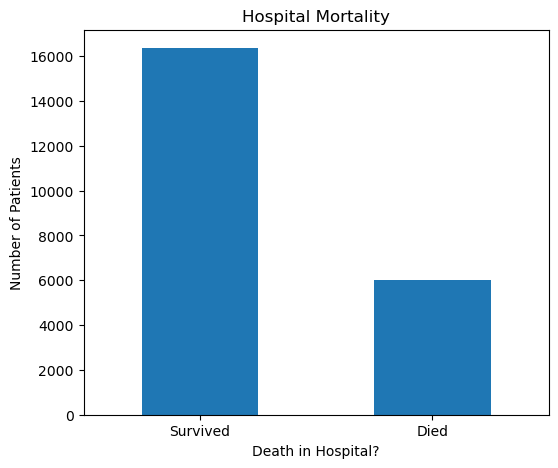

In [33]:
import matplotlib.pyplot as plt

# Print exact numbers of survived and died
counts = final_df["MORTALITY_180DAY"].value_counts()
print("Survived (0) :", counts.get(0, 0))
print("Died (1)     :", counts.get(1, 0))

# Plot bar chart
plt.figure(figsize=(6,5))
counts.plot(kind="bar")

plt.xticks([0,1], ["Survived", "Died"], rotation=0)
plt.xlabel("Death in Hospital?")
plt.ylabel("Number of Patients")
plt.title("Hospital Mortality")

plt.show()

In [40]:
from sklearn.feature_selection import mutual_info_classif

# --------------------------------------------------
# Remove ID columns (never used as features)
#(Here we remove ID columns (patient/admission/ICU IDs), because they are just identifiers and should not be used as predictors in the model.)
# --------------------------------------------------
id_cols = ["SUBJECT_ID", "HADM_ID", "ICUSTAY_ID"]
safe_final_df = final_df.drop(columns=[c for c in id_cols if c in final_df.columns])

# --------------------------------------------------
# Ensure target column exists and is numeric
# (We check that the target column MORTALITY_INHOSPITAL is present and convert it to 0/1 integers so we can calculate correlations.)
# --------------------------------------------------
target_col = "MORTALITY_180DAY"

if target_col not in safe_final_df.columns:
    raise ValueError(f"{target_col} not found in safe_final_df!")

safe_final_df[target_col] = safe_final_df[target_col].astype(int)

# --------------------------------------------------
# Numeric features – Pearson correlation
# (We take all numeric columns (except the target) and compute their Pearson correlation with mortality, then sort them from strongest to weakest relationship)
# --------------------------------------------------
numeric_cols = safe_final_df.select_dtypes(include=["number"]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != target_col]

numeric_df = safe_final_df[numeric_cols + [target_col]]

corr_with_target = (
    numeric_df.corr()[target_col]
    .drop(target_col)
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

numeric_rank = pd.DataFrame({
    "score": corr_with_target.abs(),   # importance = |r|
    "signed_corr": corr_with_target,   # store the sign separately
    "type": "numeric",
    "metric": "pearson_r"
})

# --------------------------------------------------
# Categorical features – Mutual Information
# (For non-numeric (categorical) columns, we turn the text into numbers and use mutual information to measure how much each category-based feature tells us about mortality)
# --------------------------------------------------
cat_cols = safe_final_df.select_dtypes(include=["object", "category"]).columns.tolist()

cat_rank = pd.DataFrame(columns=["score", "type", "metric"])

if len(cat_cols) > 0:
    X_cat = safe_final_df[cat_cols].copy()

    for col in cat_cols:
        X_cat[col] = X_cat[col].astype("category")
        X_cat[col] = X_cat[col].cat.add_categories("MISSING").fillna("MISSING")
        X_cat[col], _ = X_cat[col].factorize()

    mi_scores = mutual_info_classif(
        X_cat,
        safe_final_df[target_col],
        discrete_features=True,
        random_state=0
    )

    cat_rank = (
        pd.DataFrame({
            "feature": cat_cols,
            "score": mi_scores,
            "type": "categorical",
            "metric": "mutual_info",
        })
        .set_index("feature")
        .sort_values("score", ascending=False)
    )

# --------------------------------------------------
# Combine + sort all features
# --------------------------------------------------
feature_rank = pd.concat([numeric_rank, cat_rank]).sort_values("score", ascending=False)

top_n = 50
print(f"Top {top_n} most important features for  mortality_6_Months:")
print(feature_rank.head(top_n))

Top 50 most important features for  mortality_6_Months:
                    score  signed_corr         type       metric
RDW_mean         0.280906     0.280906      numeric    pearson_r
RDW_min          0.280848     0.280848      numeric    pearson_r
RDW_max          0.276979     0.276979      numeric    pearson_r
BUN_min          0.263334     0.263334      numeric    pearson_r
BUN_mean         0.256633     0.256633      numeric    pearson_r
BUN_max          0.243689     0.243689      numeric    pearson_r
DIAGNOSIS        0.235329          NaN  categorical  mutual_info
AG_mean          0.224860     0.224860      numeric    pearson_r
AGE              0.217826     0.217826      numeric    pearson_r
AG_max           0.204988     0.204988      numeric    pearson_r
AG_min           0.200293     0.200293      numeric    pearson_r
Albumin_min      0.181029    -0.181029      numeric    pearson_r
Albumin_mean     0.178927    -0.178927      numeric    pearson_r
Bilirubin_mean   0.173837     0.17

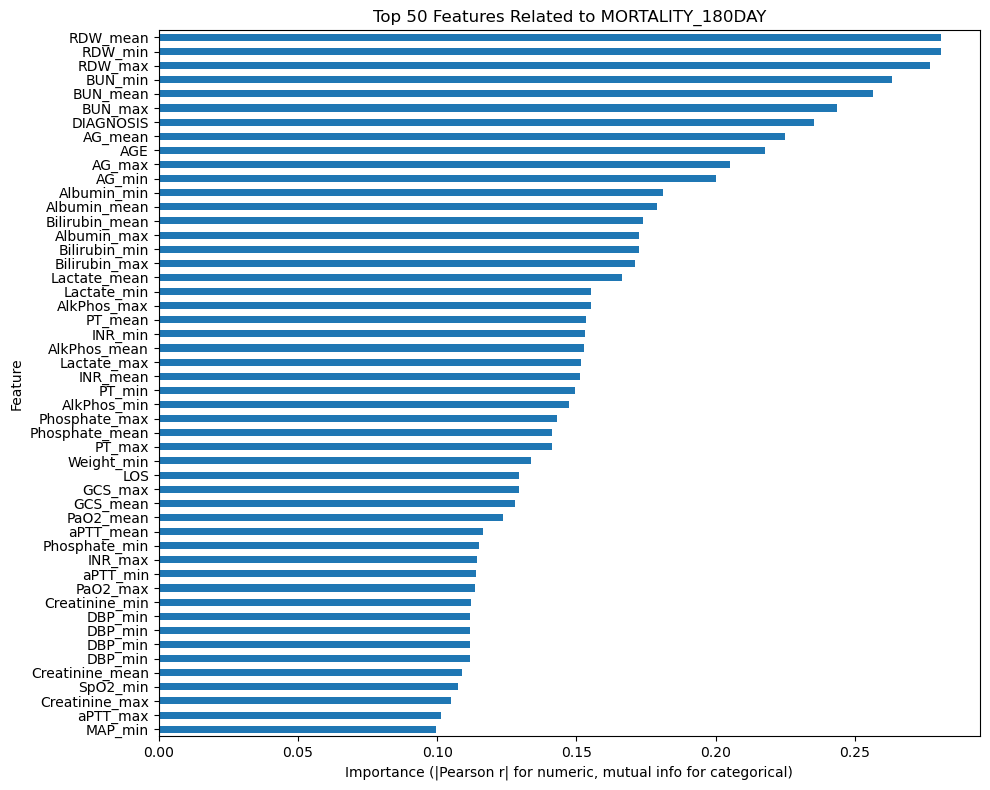

In [37]:
# --------------------------------------------------
# Bar plot of top N
# --------------------------------------------------
plt.figure(figsize=(10, 8))
(
    feature_rank.head(top_n)
    .sort_values("score")["score"]
    .plot(kind="barh")
)
plt.xlabel("Importance (|Pearson r| for numeric, mutual info for categorical)")
plt.ylabel("Feature")
plt.title(f"Top {top_n} Features Related to {target_col}")
plt.tight_layout()
plt.show()
